In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import norm, binom, kendalltau, pearsonr
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'JPM', 'V', 'JNJ']
start_date = '2022-01-01'
end_date = '2024-12-31'
print(f"   Активы: {tickers}")
print(f"   Период: {start_date} - {end_date}")
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
prices = data['Close']
returns = prices.pct_change().dropna()

n, N = returns.shape
M = N * (N - 1) // 2

print(f"   Размер выборки (n): {n} дней")
print(f"   Количество активов (N): {N}")
print(f"   Количество тестов (M): {M}")

[**********            20%                       ]  2 of 10 completed

   Активы: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'JPM', 'V', 'JNJ']
   Период: 2022-01-01 - 2024-12-31


[*********************100%***********************]  10 of 10 completed

   Размер выборки (n): 751 дней
   Количество активов (N): 10
   Количество тестов (M): 45


In [ ]:
def bonferroni_pearson_bounds(data, gamma0, confidence=0.9):
    n, N = data.shape
    M = N * (N - 1) // 2
    alpha = 1 - confidence
    alpha_adj = alpha / M

    pairs = list(combinations(range(N), 2))
    UCB, LCB = [], []

    for i, j in pairs:
        x, y = data.iloc[:, i].values, data.iloc[:, j].values
        r, _ = pearsonr(x, y)
        r_clipped = np.clip(r, -0.999999, 0.999999)
        z = 0.5 * np.log((1 + r_clipped) / (1 - r_clipped))
        z0 = 0.5 * np.log((1 + gamma0) / (1 - gamma0))
        stat = (z - z0) / (1.0 / np.sqrt(n - 3))

        crit_lower, crit_upper = norm.ppf(alpha_adj), norm.ppf(1 - alpha_adj)

        if stat >= crit_lower:
            UCB.append((i, j))
        if stat > crit_upper:
            LCB.append((i, j))

    return {
        'UCB': UCB, 'LCB': LCB,
        'UCB_size': len(UCB), 'LCB_size': len(LCB),
        'uncertainty_size': len(set(UCB) - set(LCB))
    }

def bonferroni_kendall_bounds(data, gamma0, confidence=0.9):
    n, N = data.shape
    M = N * (N - 1) // 2
    alpha = 1 - confidence
    alpha_adj = alpha / M

    pairs = list(combinations(range(N), 2))
    UCB, LCB = [], []

    for i, j in pairs:
        x, y = data.iloc[:, i].values, data.iloc[:, j].values
        tau, _ = kendalltau(x, y)
        var_tau = (2.0 * (2.0 * n + 5.0)) / (9.0 * n * (n - 1.0))
        stat = (tau - gamma0) / np.sqrt(var_tau)

        crit_lower, crit_upper = norm.ppf(alpha_adj), norm.ppf(1 - alpha_adj)

        if stat >= crit_lower:
            UCB.append((i, j))
        if stat > crit_upper:
            LCB.append((i, j))

    return {
        'UCB': UCB, 'LCB': LCB,
        'UCB_size': len(UCB), 'LCB_size': len(LCB),
        'uncertainty_size': len(set(UCB) - set(LCB))
    }

def pearson_to_sign_threshold(rho0):
    return 0.5 + np.arcsin(np.clip(rho0, -0.999999, 0.999999)) / np.pi

def bonferroni_sign_bounds(data, gamma0_sign, confidence=0.9):
    n, N = data.shape
    M = N * (N - 1) // 2
    alpha = 1 - confidence
    alpha_adj = alpha / M

    data_centered = data - data.median()
    pairs = list(combinations(range(N), 2))
    UCB, LCB = [], []

    try:
        crit_lower = binom.ppf(alpha_adj, n, gamma0_sign)
        crit_upper = binom.ppf(1 - alpha_adj, n, gamma0_sign)
    except ValueError:
        crit_lower, crit_upper = 0, n

    for i, j in pairs:
        T_stat = np.sum((data_centered.iloc[:, i].values * data_centered.iloc[:, j].values) > 0)
        if T_stat >= crit_lower:
            UCB.append((i, j))
        if T_stat > crit_upper:
            LCB.append((i, j))

    return {
        'UCB': UCB, 'LCB': LCB,
        'UCB_size': len(UCB), 'LCB_size': len(LCB),
        'uncertainty_size': len(set(UCB) - set(LCB))
    }


ТАБЛИЦА 1: ЗАВИСИМОСТЬ РАЗМЕРА ДОВЕРИТЕЛЬНОГО МНОЖЕСТВА ОТ n

   gamma0 = 0.4, P* = 0.9
   ----------------------------------------------------------------------------------------------------
   n        |LCB_Пирсон|   |LCB_Кендалл|  |LCB_Знак|     |UCB_Пирсон|   |UCB_Кендалл|  |UCB_Знак|    
   ----------------------------------------------------------------------------------------------------
   50       8              1              12             42             37             45            
   100      19             11             21             42             36             45            
   250      27             15             27             41             36             44            
   500      23             14             22             37             30             40            
   750      19             6              12             34             22             38            
   1000     19             6              11             34             22             38  

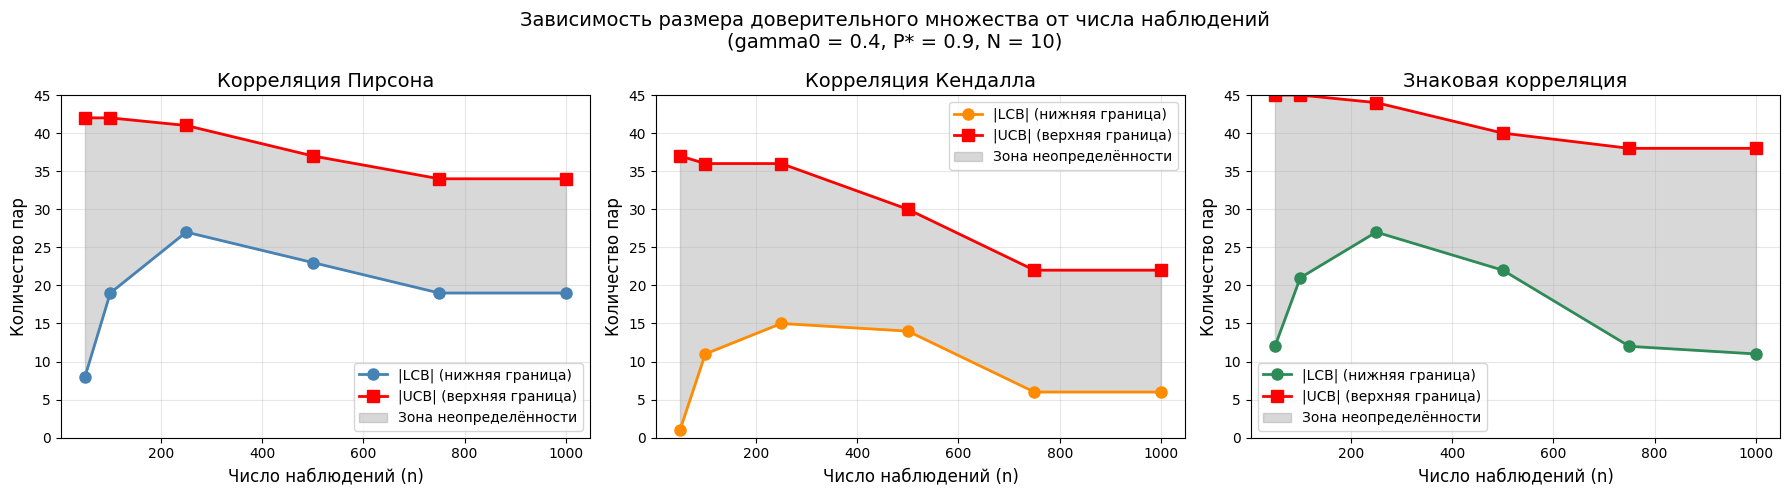


ТАБЛИЦА 2: ЗАВИСИМОСТЬ РАЗМЕРА ДОВЕРИТЕЛЬНОГО МНОЖЕСТВА ОТ N
   (сравнение Пирсона, Кендалла и знаковой корреляции)

   gamma0 = 0.4, P* = 0.9, n = 500
   ----------------------------------------------------------------------------------------------------
   N        M        |LCB_Пирсон|   |LCB_Кендалл|  |LCB_Знак|     |UCB_Пирсон|   |UCB_Кендалл|  |UCB_Знак|    
   ----------------------------------------------------------------------------------------------------
   5        10       8              6              10             10             10             10            
   8        28       18             14             20             28             23             28            
   10       45       23             14             22             37             30             40            
   ----------------------------------------------------------------------------------------------------


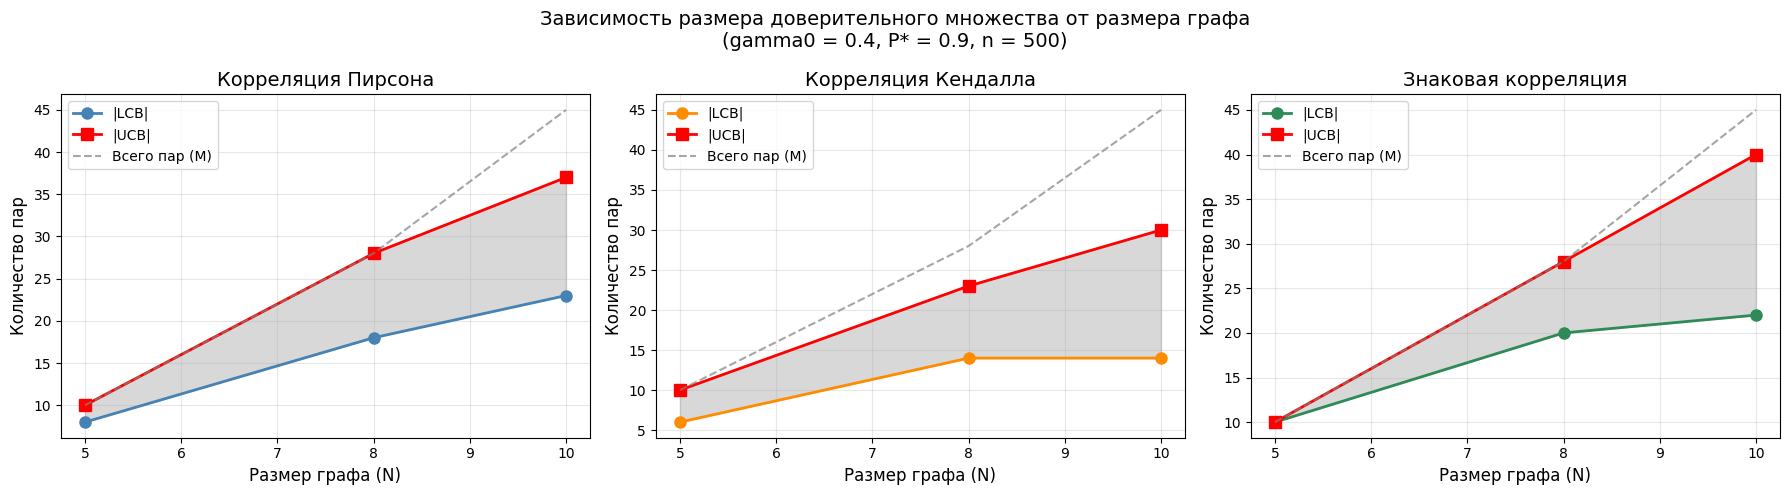


ТАБЛИЦА 3: СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ ПРИ РАЗНЫХ ПОРОГАХ gamma0

   P* = 0.9, n = 751, N = 10
   ----------------------------------------------------------------------------------------------------
   gamma0     Метод        |LCB|      |UCB|      |Неопред.|   |J\UCB|      p0 (для знак)  
   ----------------------------------------------------------------------------------------------------
   0.2        Pearson      35         41         6            4            -              
   0.2        Kendall      28         38         10           7            -              
   0.2        Sign         28         42         14           3            0.5641         
   ----------------------------------------------------------------------------------------------------
   0.3        Pearson      26         38         12           7            -              
   0.3        Kendall      16         33         17           12           -              
   0.3        Sign         24         40     

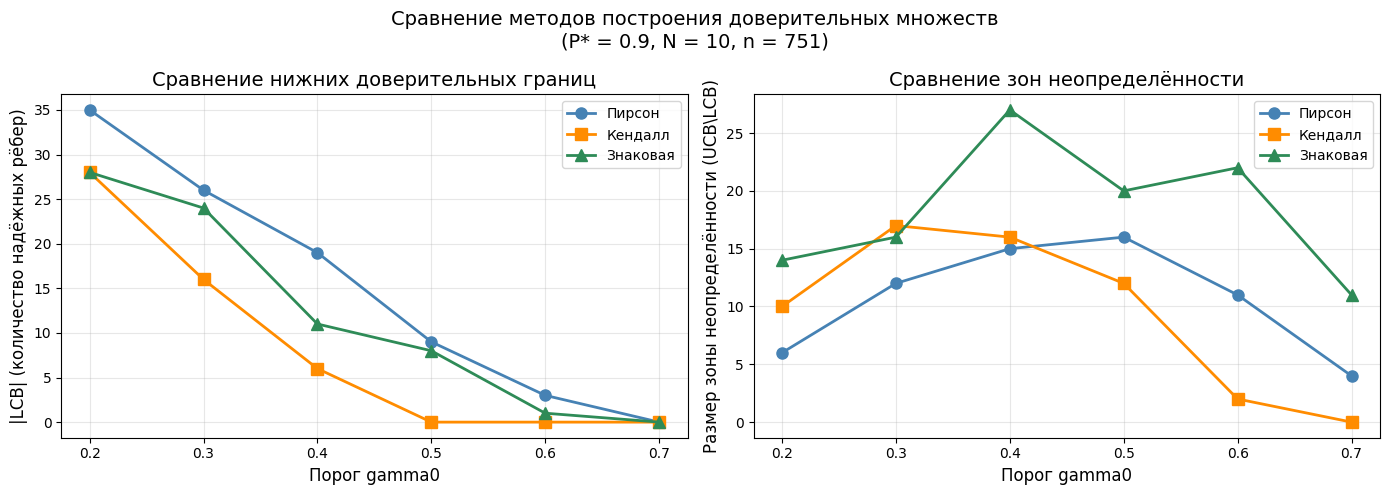


 ВИЗУАЛИЗАЦИЯ ГРАФОВ РЫНКА
   (gamma0 = 0.5, P* = 0.9)

   Параметры: gamma0 = 0.5, P* = 0.9
   Порог знаковой корреляции: p0 = 0.6667

   Результаты:
   Pearson:   |LCB|=9, |UCB|=25, неопр.=16
   Kendall:   |LCB|=0, |UCB|=12, неопр.=12
   Sign:      |LCB|=8, |UCB|=28, неопр.=20


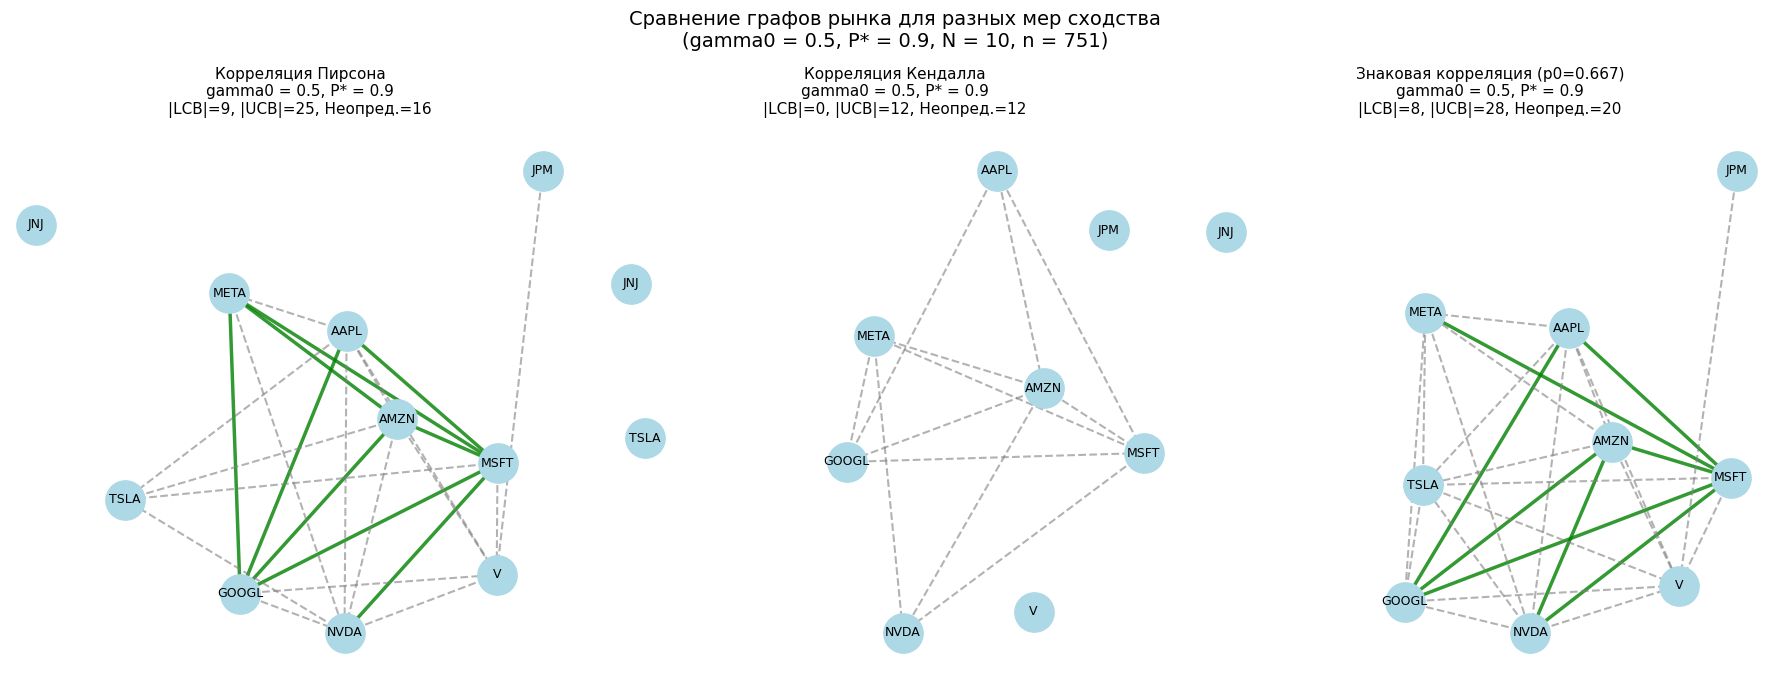


   Таблица 4: Сводные результаты для всех методов
   ------------------------------------------------------------------------------------------
 gamma0     p0  pearson_LCB  pearson_UCB  pearson_unc  kendall_LCB  kendall_UCB  kendall_unc  sign_LCB  sign_UCB  sign_unc
    0.2 0.5641           35           41            6           28           38           10        28        42        14
    0.3 0.5970           26           38           12           16           33           17        24        40        16
    0.4 0.6310           19           34           15            6           22           16        11        38        27
    0.5 0.6667            9           25           16            0           12           12         8        28        20
    0.6 0.7048            3           14           11            0            2            2         1        23        22
    0.7 0.7468            0            4            4            0            0            0         0        11     

In [ ]:
print("\nТАБЛИЦА 1: ЗАВИСИМОСТЬ РАЗМЕРА ДОВЕРИТЕЛЬНОГО МНОЖЕСТВА ОТ n")
CONFIDENCE = 0.9
GAMMA0 = 0.4
SAMPLE_SIZES = [50, 100, 250, 500, 750, 1000]

results_by_n = []

print(f"\n   gamma0 = {GAMMA0}, P* = {CONFIDENCE}")
print("   " + "-" * 100)
print(f"   {'n':<8} {'|LCB_Пирсон|':<14} {'|LCB_Кендалл|':<14} {'|LCB_Знак|':<14} {'|UCB_Пирсон|':<14} {'|UCB_Кендалл|':<14} {'|UCB_Знак|':<14}")
print("   " + "-" * 100)

for sample_n in SAMPLE_SIZES:
    data_subset = returns.iloc[:sample_n, :]
    p0 = pearson_to_sign_threshold(GAMMA0)

    pearson_res = bonferroni_pearson_bounds(data_subset, GAMMA0, CONFIDENCE)
    kendall_res = bonferroni_kendall_bounds(data_subset, GAMMA0, CONFIDENCE)
    sign_res = bonferroni_sign_bounds(data_subset, p0, CONFIDENCE)

    results_by_n.append({
        'n': sample_n,
        'pearson_LCB': pearson_res['LCB_size'], 'pearson_UCB': pearson_res['UCB_size'],
        'kendall_LCB': kendall_res['LCB_size'], 'kendall_UCB': kendall_res['UCB_size'],
        'sign_LCB': sign_res['LCB_size'], 'sign_UCB': sign_res['UCB_size'],
    })

    print(f"   {sample_n:<8} {pearson_res['LCB_size']:<14} {kendall_res['LCB_size']:<14} {sign_res['LCB_size']:<14} "
          f"{pearson_res['UCB_size']:<14} {kendall_res['UCB_size']:<14} {sign_res['UCB_size']:<14}")

print("   " + "-" * 100)

# График зависимости от n для всех трёх методов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = ['pearson', 'kendall', 'sign']
titles = ['Корреляция Пирсона', 'Корреляция Кендалла', 'Знаковая корреляция']
colors = ['steelblue', 'darkorange', 'seagreen']

for idx, (method, title, color) in enumerate(zip(methods, titles, colors)):
    ax = axes[idx]
    lcb_vals = [r[f'{method}_LCB'] for r in results_by_n]
    ucb_vals = [r[f'{method}_UCB'] for r in results_by_n]

    ax.plot(SAMPLE_SIZES, lcb_vals, 'o-', label='|LCB| (нижняя граница)', color=color, linewidth=2, markersize=8)
    ax.plot(SAMPLE_SIZES, ucb_vals, 's-', label='|UCB| (верхняя граница)', color='red', linewidth=2, markersize=8)
    ax.fill_between(SAMPLE_SIZES, lcb_vals, ucb_vals, alpha=0.3, color='gray', label='Зона неопределённости')
    ax.set_xlabel('Число наблюдений (n)', fontsize=12)
    ax.set_ylabel('Количество пар', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, M)

plt.suptitle(f'Зависимость размера доверительного множества от числа наблюдений\n(gamma0 = {GAMMA0}, P* = {CONFIDENCE}, N = {N})', fontsize=14)
plt.tight_layout()
plt.savefig('dependency_on_n.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nТАБЛИЦА 2: ЗАВИСИМОСТЬ РАЗМЕРА ДОВЕРИТЕЛЬНОГО МНОЖЕСТВА ОТ N")
print("   (сравнение Пирсона, Кендалла и знаковой корреляции)")

GAMMA0 = 0.4
CONFIDENCE = 0.9
FIXED_N_OBS = 500

asset_subsets = {}
for n_assets in [5, 8, 10]:
    asset_subsets[n_assets] = tickers[:n_assets]

results_by_N = []

print(f"\n   gamma0 = {GAMMA0}, P* = {CONFIDENCE}, n = {FIXED_N_OBS}")
print("   " + "-" * 100)
print(f"   {'N':<8} {'M':<8} {'|LCB_Пирсон|':<14} {'|LCB_Кендалл|':<14} {'|LCB_Знак|':<14} {'|UCB_Пирсон|':<14} {'|UCB_Кендалл|':<14} {'|UCB_Знак|':<14}")
print("   " + "-" * 100)

for N_assets, asset_list in asset_subsets.items():
    data_subset = returns[asset_list].iloc[:FIXED_N_OBS, :]
    n_actual, N_actual = data_subset.shape
    M_actual = N_actual * (N_actual - 1) // 2
    p0 = pearson_to_sign_threshold(GAMMA0)

    pearson_res = bonferroni_pearson_bounds(data_subset, GAMMA0, CONFIDENCE)
    kendall_res = bonferroni_kendall_bounds(data_subset, GAMMA0, CONFIDENCE)
    sign_res = bonferroni_sign_bounds(data_subset, p0, CONFIDENCE)

    results_by_N.append({
        'N': N_actual, 'M': M_actual,
        'pearson_LCB': pearson_res['LCB_size'], 'pearson_UCB': pearson_res['UCB_size'],
        'kendall_LCB': kendall_res['LCB_size'], 'kendall_UCB': kendall_res['UCB_size'],
        'sign_LCB': sign_res['LCB_size'], 'sign_UCB': sign_res['UCB_size']
    })

    print(f"   {N_actual:<8} {M_actual:<8} {pearson_res['LCB_size']:<14} {kendall_res['LCB_size']:<14} {sign_res['LCB_size']:<14} "
          f"{pearson_res['UCB_size']:<14} {kendall_res['UCB_size']:<14} {sign_res['UCB_size']:<14}")

print("   " + "-" * 100)

# График зависимости от N
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (method, title, color) in enumerate(zip(methods, titles, colors)):
    ax = axes[idx]
    lcb_vals = [r[f'{method}_LCB'] for r in results_by_N]
    ucb_vals = [r[f'{method}_UCB'] for r in results_by_N]
    m_vals = [r['M'] for r in results_by_N]
    n_vals = [r['N'] for r in results_by_N]

    ax.plot(n_vals, lcb_vals, 'o-', label='|LCB|', color=color, linewidth=2, markersize=8)
    ax.plot(n_vals, ucb_vals, 's-', label='|UCB|', color='red', linewidth=2, markersize=8)
    ax.plot(n_vals, m_vals, '--', label='Всего пар (M)', color='gray', alpha=0.7)
    ax.fill_between(n_vals, lcb_vals, ucb_vals, alpha=0.3, color='gray')
    ax.set_xlabel('Размер графа (N)', fontsize=12)
    ax.set_ylabel('Количество пар', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Зависимость размера доверительного множества от размера графа\n(gamma0 = {GAMMA0}, P* = {CONFIDENCE}, n = {FIXED_N_OBS})', fontsize=14)
plt.tight_layout()
plt.savefig('dependency_on_N.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nТАБЛИЦА 3: СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ ПРИ РАЗНЫХ ПОРОГАХ gamma0")

THRESHOLDS = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
CONFIDENCE = 0.9

print(f"\n   P* = {CONFIDENCE}, n = {n}, N = {N}")
print("   " + "-" * 100)
print(f"   {'gamma0':<10} {'Метод':<12} {'|LCB|':<10} {'|UCB|':<10} {'|Неопред.|':<12} {'|J\\UCB|':<12} {'p0 (для знак)':<15}")
print("   " + "-" * 100)

comparison_results = []

for gamma0 in THRESHOLDS:
    p0 = pearson_to_sign_threshold(gamma0)
    pearson_res = bonferroni_pearson_bounds(returns, gamma0, CONFIDENCE)
    kendall_res = bonferroni_kendall_bounds(returns, gamma0, CONFIDENCE)
    sign_res = bonferroni_sign_bounds(returns, p0, CONFIDENCE)

    comparison_results.append({
        'gamma0': gamma0, 'p0': p0,
        'pearson_LCB': pearson_res['LCB_size'], 'pearson_UCB': pearson_res['UCB_size'], 'pearson_unc': pearson_res['uncertainty_size'],
        'kendall_LCB': kendall_res['LCB_size'], 'kendall_UCB': kendall_res['UCB_size'], 'kendall_unc': kendall_res['uncertainty_size'],
        'sign_LCB': sign_res['LCB_size'], 'sign_UCB': sign_res['UCB_size'], 'sign_unc': sign_res['uncertainty_size']
    })

    print(f"   {gamma0:<10.1f} {'Pearson':<12} {pearson_res['LCB_size']:<10} {pearson_res['UCB_size']:<10} {pearson_res['uncertainty_size']:<12} {M - pearson_res['UCB_size']:<12} {'-':<15}")
    print(f"   {gamma0:<10.1f} {'Kendall':<12} {kendall_res['LCB_size']:<10} {kendall_res['UCB_size']:<10} {kendall_res['uncertainty_size']:<12} {M - kendall_res['UCB_size']:<12} {'-':<15}")
    print(f"   {gamma0:<10.1f} {'Sign':<12} {sign_res['LCB_size']:<10} {sign_res['UCB_size']:<10} {sign_res['uncertainty_size']:<12} {M - sign_res['UCB_size']:<12} {p0:<15.4f}")
    print("   " + "-" * 100)

# График сравнения методов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График LCB для всех методов
ax = axes[0]
pearson_lcb = [r['pearson_LCB'] for r in comparison_results]
kendall_lcb = [r['kendall_LCB'] for r in comparison_results]
sign_lcb = [r['sign_LCB'] for r in comparison_results]

ax.plot(THRESHOLDS, pearson_lcb, 'o-', label='Пирсон', color='steelblue', linewidth=2, markersize=8)
ax.plot(THRESHOLDS, kendall_lcb, 's-', label='Кендалл', color='darkorange', linewidth=2, markersize=8)
ax.plot(THRESHOLDS, sign_lcb, '^-', label='Знаковая', color='seagreen', linewidth=2, markersize=8)
ax.set_xlabel('Порог gamma0', fontsize=12)
ax.set_ylabel('|LCB| (количество надёжных рёбер)', fontsize=12)
ax.set_title('Сравнение нижних доверительных границ', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# График зоны неопределённости
ax = axes[1]
pearson_unc = [r['pearson_unc'] for r in comparison_results]
kendall_unc = [r['kendall_unc'] for r in comparison_results]
sign_unc = [r['sign_unc'] for r in comparison_results]

ax.plot(THRESHOLDS, pearson_unc, 'o-', label='Пирсон', color='steelblue', linewidth=2, markersize=8)
ax.plot(THRESHOLDS, kendall_unc, 's-', label='Кендалл', color='darkorange', linewidth=2, markersize=8)
ax.plot(THRESHOLDS, sign_unc, '^-', label='Знаковая', color='seagreen', linewidth=2, markersize=8)
ax.set_xlabel('Порог gamma0', fontsize=12)
ax.set_ylabel('Размер зоны неопределённости (UCB\\LCB)', fontsize=12)
ax.set_title('Сравнение зон неопределённости', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Сравнение методов построения доверительных множеств\n(P* = {CONFIDENCE}, N = {N}, n = {n})', fontsize=14)
plt.tight_layout()
plt.savefig('methods_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n ВИЗУАЛИЗАЦИЯ ГРАФОВ РЫНКА")
print("   (gamma0 = 0.5, P* = 0.9)")

def plot_market_graph(returns, result, title, gamma0, confidence, method_name, ax=None):
    N = returns.shape[1]
    tickers_list = returns.columns.tolist()
    ucb_set = set(result['UCB'])
    lcb_set = set(result['LCB'])

    significant_edges = lcb_set
    uncertain_edges = ucb_set - lcb_set

    G = nx.Graph()
    G.add_nodes_from(range(N))
    for i, j in significant_edges:
        G.add_edge(i, j, type='significant')
    for i, j in uncertain_edges:
        G.add_edge(i, j, type='uncertain')

    if ax is None:
        plt.figure(figsize=(12, 10))
        ax = plt.gca()

    pos = nx.spring_layout(G, seed=42, k=2, iterations=50)

    sig_edges = [(u, v) for (u, v, d) in G.edges(data=True) if d['type'] == 'significant']
    unc_edges = [(u, v) for (u, v, d) in G.edges(data=True) if d['type'] == 'uncertain']

    if sig_edges:
        nx.draw_networkx_edges(G, pos, edgelist=sig_edges, edge_color='green', width=2.5, alpha=0.8, ax=ax)
    if unc_edges:
        nx.draw_networkx_edges(G, pos, edgelist=unc_edges, edge_color='gray', width=1.5, alpha=0.6, style='dashed', ax=ax)

    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=800, ax=ax)
    nx.draw_networkx_labels(G, pos, {i: tickers_list[i] for i in range(N)}, font_size=9, ax=ax)

    ax.set_title(f'{method_name}\ngamma0 = {gamma0}, P* = {confidence}\n|LCB|={len(significant_edges)}, |UCB|={len(ucb_set)}, Неопред.={len(uncertain_edges)}', fontsize=11)
    ax.axis('off')
    return G

GAMMA0_VIS = 0.5
CONFIDENCE_VIS = 0.9
p0_vis = pearson_to_sign_threshold(GAMMA0_VIS)

pearson_vis = bonferroni_pearson_bounds(returns, GAMMA0_VIS, CONFIDENCE_VIS)
kendall_vis = bonferroni_kendall_bounds(returns, GAMMA0_VIS, CONFIDENCE_VIS)
sign_vis = bonferroni_sign_bounds(returns, p0_vis, CONFIDENCE_VIS)

print(f"\n   Параметры: gamma0 = {GAMMA0_VIS}, P* = {CONFIDENCE_VIS}")
print(f"   Порог знаковой корреляции: p0 = {p0_vis:.4f}")
print(f"\n   Результаты:")
print(f"   Pearson:   |LCB|={pearson_vis['LCB_size']}, |UCB|={pearson_vis['UCB_size']}, неопр.={pearson_vis['uncertainty_size']}")
print(f"   Kendall:   |LCB|={kendall_vis['LCB_size']}, |UCB|={kendall_vis['UCB_size']}, неопр.={kendall_vis['uncertainty_size']}")
print(f"   Sign:      |LCB|={sign_vis['LCB_size']}, |UCB|={sign_vis['UCB_size']}, неопр.={sign_vis['uncertainty_size']}")

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
plot_market_graph(returns, pearson_vis, 'Граф рынка', GAMMA0_VIS, CONFIDENCE_VIS, 'Корреляция Пирсона', axes[0])
plot_market_graph(returns, kendall_vis, 'Граф рынка', GAMMA0_VIS, CONFIDENCE_VIS, 'Корреляция Кендалла', axes[1])
plot_market_graph(returns, sign_vis, 'Граф рынка', GAMMA0_VIS, CONFIDENCE_VIS, f'Знаковая корреляция (p0={p0_vis:.3f})', axes[2])
plt.suptitle(f'Сравнение графов рынка для разных мер сходства\n(gamma0 = {GAMMA0_VIS}, P* = {CONFIDENCE_VIS}, N = {N}, n = {n})', fontsize=14)
plt.tight_layout()
plt.savefig('market_graphs.png', dpi=150, bbox_inches='tight')
plt.show()


summary_df = pd.DataFrame(comparison_results)
print("\n   Таблица 4: Сводные результаты для всех методов")
print("   " + "-" * 90)
print(summary_df.round(4).to_string(index=False))
print("   " + "-" * 90)

summary_df.to_csv('confidence_bounds_summary.csv', index=False)